# 1. Final parquet analysis

In [4]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Configure plotting style
plt.style.use('ggplot')
sns.set_palette("husl")

DATA_PATH = "../data/merged_final_2.parquet"
URL_COL = "domain"
# Attempt to identify label and text columns usually found in such datasets
TEXT_COL = "text" 
LABEL_COL = "classification" # adjust if your dataset uses 'class', 'category', etc.

def calculate_entropy(s: str) -> float:
    if not s:
        return 0.0
    counts = Counter(s)
    length = len(s)
    probs = [c / length for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

try:
    df = pl.read_parquet(DATA_PATH)
    print(f"Loaded dataset from {DATA_PATH}. Shape: {df.shape}")
    print("Columns:", df.columns)
    
    # Auto-detect label column if default doesn't exist
    if LABEL_COL not in df.columns:
        possible_labels = ["class", "category", "type", "label"]
        for col in possible_labels:
            if col in df.columns:
                LABEL_COL = col
                break
    print(f"Using Label Column: {LABEL_COL}")

except Exception as e:
    print(f"Error loading data: {e}")


Loaded dataset from ../data/merged_final_2.parquet. Shape: (19405, 3)
Columns: ['domain', 'classification', 'text']
Using Label Column: classification


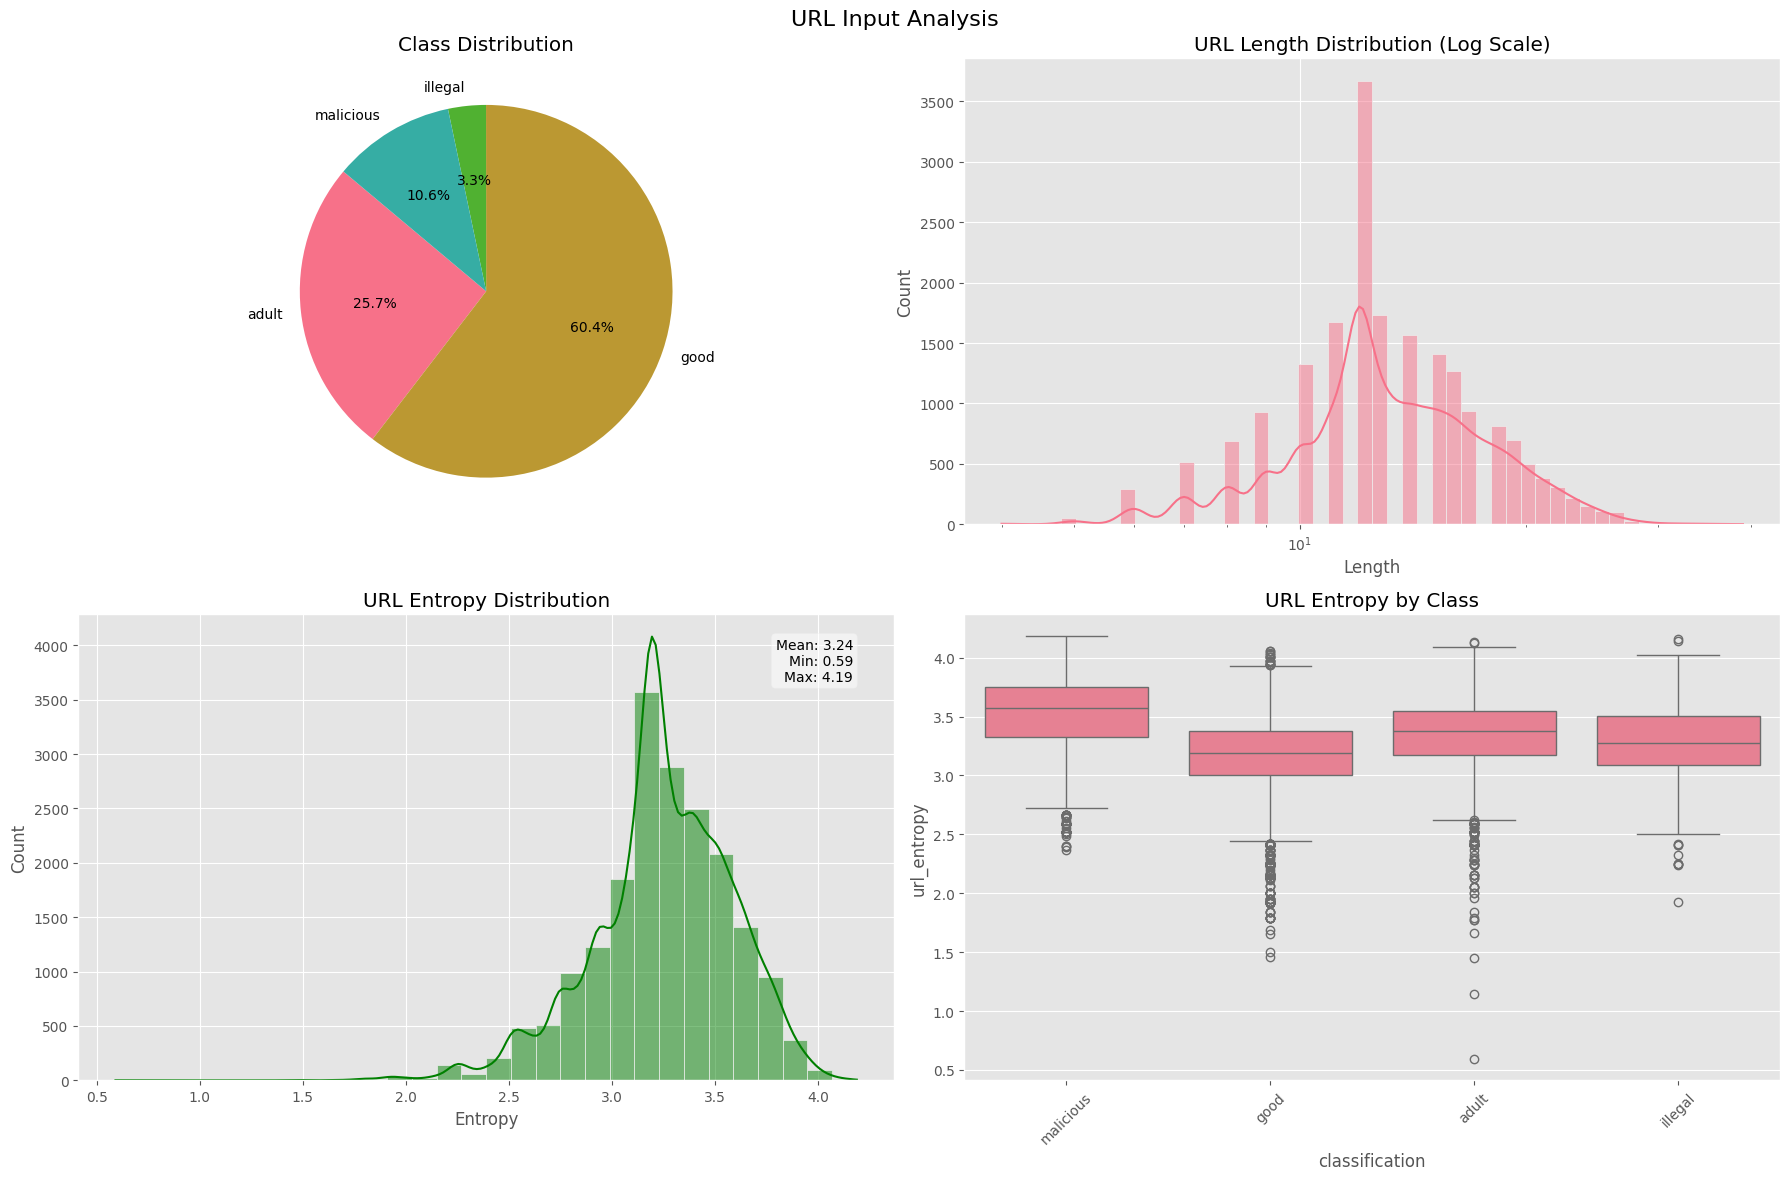

<Figure size 640x480 with 0 Axes>

In [11]:
# --- URL Input Analysis ---

# 1. Feature Engineering for Analysis
if URL_COL in df.columns:
    # Calculate URL Length
    df = df.with_columns(
        pl.col(URL_COL).str.len_bytes().alias("url_length")
    )
    
    # Calculate Entropy
    # Polars map_elements might be slow for huge datasets, but okay for analysis
    df = df.with_columns(
        pl.col(URL_COL).map_elements(calculate_entropy, return_dtype=pl.Float64).alias("url_entropy")
    )

    # 2. Plots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12)) 
    fig.suptitle('URL Input Analysis', fontsize=16)

    # A. Class Distribution
    if LABEL_COL in df.columns:
        class_counts = df[LABEL_COL].value_counts().sort(LABEL_COL)
        axes[0, 0].pie(class_counts["count"], labels=class_counts[LABEL_COL], autopct='%1.1f%%', startangle=140)
        axes[0, 0].set_title('Class Distribution')
    else:
        axes[0, 0].text(0.5, 0.5, 'Label column not found', ha='center')

    # B. URL Length Distribution (Log Scale)
    sns.histplot(data=df["url_length"].to_list(), bins=50, ax=axes[0, 1], kde=True, log_scale=(True, False))
    axes[0, 1].set_title('URL Length Distribution (Log Scale)')
    axes[0, 1].set_xlabel('Length')

    # C. Entropy Statistics
    sns.histplot(data=df["url_entropy"].to_list(), bins=30, ax=axes[1, 0], kde=True, color='green')
    axes[1, 0].set_title('URL Entropy Distribution')
    axes[1, 0].set_xlabel('Entropy')
    
    # Add stats text box
    entropy_stats = df["url_entropy"].describe()
    stats_text = f"Mean: {df['url_entropy'].mean():.2f}\nMin: {df['url_entropy'].min():.2f}\nMax: {df['url_entropy'].max():.2f}"
    axes[1, 0].text(0.95, 0.95, stats_text, transform=axes[1, 0].transAxes, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    # D. Entropy by Class
    if LABEL_COL in df.columns:
        # Convert to pandas for easier boxplotting with seaborn
        pd_df = df.select([LABEL_COL, "url_entropy"]).to_pandas()
        sns.boxplot(x=LABEL_COL, y="url_entropy", data=pd_df, ax=axes[1, 1])
        axes[1, 1].set_title('URL Entropy by Class')
        axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{URL_COL}' not found.")

plt.savefig("/home/rocminfo/Templates/CyberCerberus/assets/confusion_matrix.png")


/tmp/ipykernel_287962/4042940962.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts, y=top_words, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_287962/4042940962.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_gram_counts, y=top_gram_words, ax=axes[1, 1], palette='magma')
/tmp/ipykernel_287962/4042940962.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_gram_counts, y=top_gram_words, ax=axes[1, 1], palette='magma')


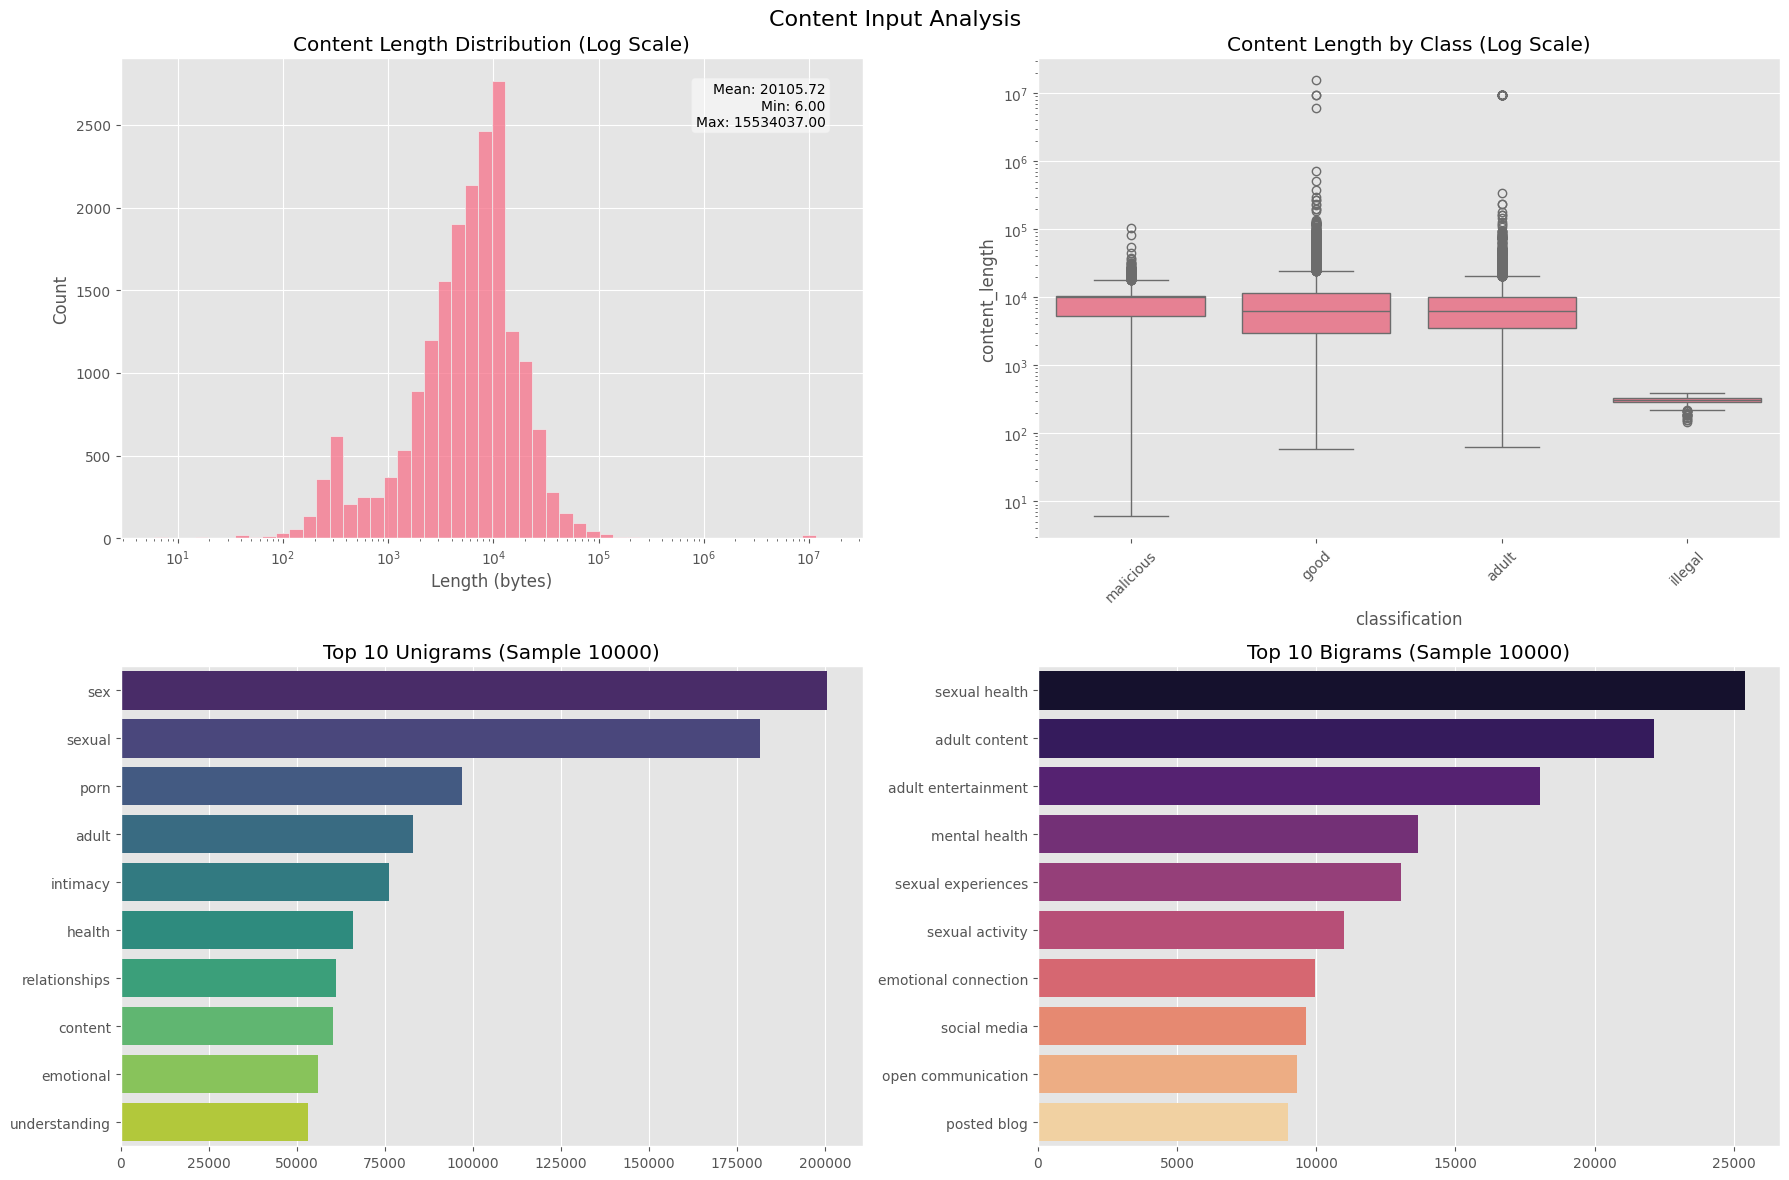

In [9]:
# --- URL Content Input Analysis ---

if TEXT_COL in df.columns:
    # 1. Feature Engineering
    # Fill nulls with empty string
    df = df.with_columns(pl.col(TEXT_COL).fill_null(""))
    
    df = df.with_columns(
        pl.col(TEXT_COL).str.len_bytes().alias("content_length")
    )

    # 2. Plots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Content Input Analysis', fontsize=16)

    # A. Content Length Stats
    sns.histplot(data=df["content_length"].to_list(), bins=50, ax=axes[0, 0], log_scale=(True, False))
    axes[0, 0].set_title('Content Length Distribution (Log Scale)')
    axes[0, 0].set_xlabel('Length (bytes)')
    
    stats_text = f"Mean: {df['content_length'].mean():.2f}\nMin: {df['content_length'].min():.2f}\nMax: {df['content_length'].max():.2f}"
    axes[0, 0].text(0.95, 0.95, stats_text, transform=axes[0, 0].transAxes, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    # B. Content Length by Class
    if LABEL_COL in df.columns:
        pd_df = df.select([LABEL_COL, "content_length"]).to_pandas()
        sns.boxplot(x=LABEL_COL, y="content_length", data=pd_df, ax=axes[0, 1])
        axes[0, 1].set_yscale("log")
        axes[0, 1].set_title('Content Length by Class (Log Scale)')
        axes[0, 1].tick_params(axis='x', rotation=45)

    # C. N-Gram Analysis (Top 20 Unigrams)
    # Using a sample if dataset is too large to prevent OOM
    sample_size = min(10000, len(df))
    text_sample = df[TEXT_COL].sample(sample_size, seed=42).to_list()
    
    vec = CountVectorizer(stop_words='english', max_features=20).fit(text_sample)
    bag_of_words = vec.transform(text_sample)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    top_words = [x[0] for x in words_freq[:10]]
    top_counts = [x[1] for x in words_freq[:10]]
    
    sns.barplot(x=top_counts, y=top_words, ax=axes[1, 0], palette='viridis')
    axes[1, 0].set_title(f'Top 10 Unigrams (Sample {sample_size})')

    # D. N-Gram Analysis (Top 15 Bigrams)
    vec_gram = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10).fit(text_sample)
    bag_of_words_gram = vec_gram.transform(text_sample)
    sum_words_gram = bag_of_words_gram.sum(axis=0) 
    words_freq_gram = [(word, sum_words_gram[0, idx]) for word, idx in vec_gram.vocabulary_.items()]
    words_freq_gram = sorted(words_freq_gram, key = lambda x: x[1], reverse=True)
    
    top_gram_words = [x[0] for x in words_freq_gram]
    top_gram_counts = [x[1] for x in words_freq_gram]

    sns.barplot(x=top_gram_counts, y=top_gram_words, ax=axes[1, 1], palette='magma')
    axes[1, 1].set_title(f'Top 10 Bigrams (Sample {sample_size})')

    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{TEXT_COL}' not found.")
